In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt


In [20]:
df = pd.read_csv(r'C:\Users\dell\Downloads\heart.csv')
print(df.head(5))
dt = (df.loc[:, df.columns != 'target'])
print(dt.head(5))
print(df.isnull().sum())
print(df.info())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161   

In [4]:
df['age'] = (df['age'] - df['age'].mean())/df['age'].std()
df['trestbps'] = (df['trestbps'] - df['trestbps'].mean())/df['trestbps'].std()
df['chol'] = (df['chol'] - df['chol'].mean())/df['chol'].std()
df['thalach'] = (df['thalach'] - df['thalach'].mean())/df['thalach'].std()
df['oldpeak'] = (df['oldpeak'] - df['oldpeak'].mean())/df['oldpeak'].std()
print(df)


           age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0    -0.268306    1   0 -0.377451 -0.659010    0        1  0.820920      0   
1    -0.158080    1   0  0.478874 -0.833454    1        0  0.255843      1   
2     1.715758    1   0  0.764315 -1.395551    0        1 -1.048180      1   
3     0.723726    1   0  0.935580 -0.833454    0        1  0.516648      0   
4     0.833952    0   0  0.364697  0.930368    1        1 -1.874062      0   
...        ...  ...  ..       ...       ...  ...      ...       ...    ...   
1020  0.503275    1   1  0.478874 -0.484566    0        1  0.647050      1   
1021  0.613500    1   0 -0.377451  0.232592    0        0 -0.352701      1   
1022 -0.819434    1   0 -1.233776  0.562097    0        0 -1.352452      1   
1023 -0.488757    0   0 -1.233776  0.155061    0        0  0.429713      0   
1024 -0.047854    1   0 -0.662893 -1.124194    0        1 -1.569790      0   

       oldpeak  slope  ca  thal  target  
0    -0.060859      2

In [5]:
columns = np.column_stack(dt)
columns = np.squeeze(columns)
X = np.column_stack([df[columns]])
print(columns)# print(X)
np.set_printoptions(threshold=2)
print(X.shape)
ones = np.ones((X.shape[0], 1))
X = np.column_stack((ones, X))
print(X.shape)
print(X)
y = df['target']
m, n = X.shape


['age' 'sex' 'cp' 'trestbps' 'chol' 'fbs' 'restecg' 'thalach' 'exang'
 'oldpeak' 'slope' 'ca' 'thal']
(1025, 13)
(1025, 14)
[[ 1.         -0.26830561  1.         ...  2.          2.
   3.        ]
 [ 1.         -0.15807986  1.         ...  0.          0.
   3.        ]
 [ 1.          1.7157579   1.         ...  0.          0.
   3.        ]
 ...
 [ 1.         -0.81943436  1.         ...  1.          1.
   2.        ]
 [ 1.         -0.48875711  0.         ...  2.          0.
   2.        ]
 [ 1.         -0.04785411  1.         ...  1.          1.
   3.        ]]


In [6]:
w = np.zeros(X.shape[1])
print(w.shape)



(14,)


In [7]:
learning_rate = 0.01
epochs = 1000


In [8]:
for epoch in range(epochs):
    z = np.dot(X, w)
    p = 1/(1+np.exp(-z))
    loss = -(1/m)*(np.sum((y.T @ np.log(p)) + (1-y.T)@np.log(1-p)))
    dw = (1/m)*(X.T @(p-y))
    w = w - learning_rate*dw


In [9]:
z = np.dot(X, w)
print(z, p)
print(w.shape)


[-0.73551812 -2.46315097 -2.77444101 ... -1.71594307  1.24532166
 -1.77889114] [0.32406725 0.07856018 0.05876643 ... 0.15248007 0.77641563 0.14450383]
(14,)


In [ ]:
def prediction(input_vector, w):
    input_vector = (input_vector - X.mean())/X.std()
    z = w@np.insert(input_vector, 0, 1)
    p = 1/(1 + np.exp(-z))
    return p


In [21]:
#age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
print(df.iloc[0])
input_data = [71,0,0,112,149,0,1,125,0,1.6,1,0,2]
print(input_data)
r = (prediction(input_data, w)>=0.5).astype(int)
print(f'The probability of getting a heart attack is {r}')
print('likely to have an heart attack' if r >= 0.5 else 'not likely to have a heart attack')


age          52.0
sex           1.0
cp            0.0
trestbps    125.0
chol        212.0
fbs           0.0
restecg       1.0
thalach     168.0
exang         0.0
oldpeak       1.0
slope         2.0
ca            2.0
thal          3.0
target        0.0
Name: 0, dtype: float64
[71, 0, 0, 112, 149, 0, 1, 125, 0, 1.6, 1, 0, 2]
The probability of getting a heart attack is 1
likely to have an heart attack


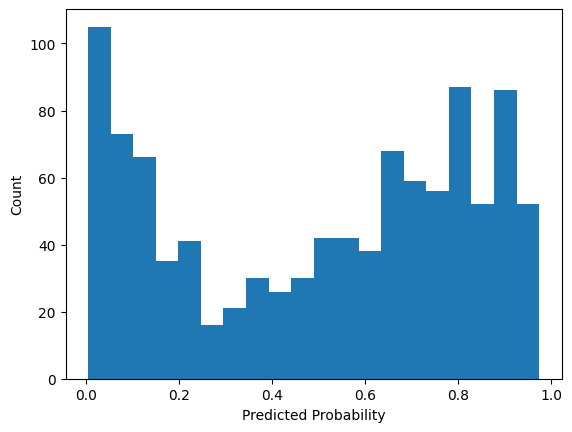

In [31]:
probabilities = 1/(1+np.exp(-(X @ w)))

plt.hist(probabilities, bins=20)
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.show()
